In [2]:
import pandas as pd
import scipy as sp
import numpy as np
import matplotlib.pyplot as plt

# P1

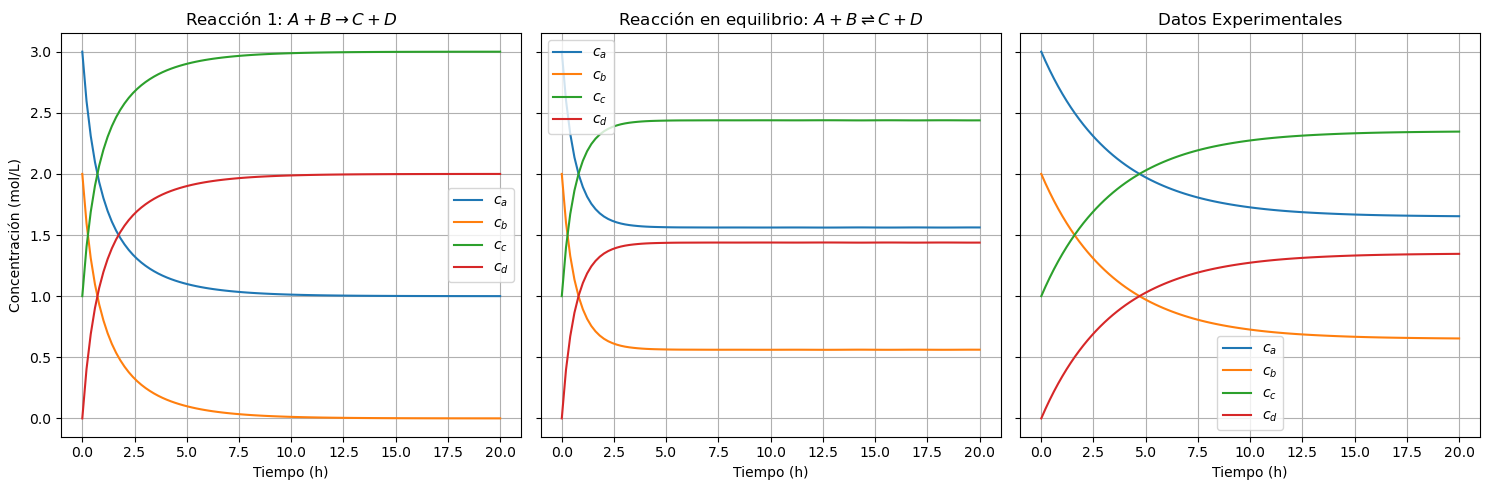

In [ ]:
# P1
# definimos las funciones para cada sistema de reacciones

def reaccion1(t, x, k1):
    '''
    A + B ->^{k1} C + D
    '''
    a,b,c,d = x
    ra =rb= -k1*a*b
    rc = rd = k1*a*b
    dca_dt = ra
    dcb_dt = rb
    dcc_dt = rc
    dcd_dt = rd
    return [dca_dt, dcb_dt, dcc_dt, dcd_dt]
def equilibrio1(t, x, k1, k_n1):
    '''
    A + B <->^{k1}_{k-1} C + D
    '''
    a,b,c,d = x
    ra = -k1*a*b + k_n1*c*d
    rb = -k1*a*b + k_n1*c*d
    rc = k1*a*b - k_n1*c*d
    rd = k1*a*b - k_n1*c*d
    dca_dt = ra
    dcb_dt = rb
    dcc_dt = rc
    dcd_dt = rd
    return [dca_dt, dcb_dt, dcc_dt, dcd_dt]

def systema_generador(t, x, k1, k_n1):
    '''
    Generador de los datos experimentales sintéticos.
    '''
    a, b, c, d = x
    ra = rb = - k1 * a** 1/3  * b ** 1/2  + k_n1 * c ** 1/2 * d**2/3
    rc = rd = - ra
    dca_dt = ra
    dcb_dt = rb
    dcc_dt = rc
    dcd_dt = rd
    return [dca_dt, dcb_dt, dcc_dt, dcd_dt]



t_span = [0, 20] # limites de integracion [min]
C0 = [3.0, 2.0, 1, 0.0] # condiciones iniciales: ca(0) = 1.0, cb(0) = 3.0, cc(0) = 0.0
t_eval = np.linspace(0, t_span[1], 100) # 100 puntos equiespaciados
ks = [0.4, 0.1] # valores de k1 y k-1

sol_r1 = sp.integrate.solve_ivp(reaccion1, t_span, C0, args=(ks[0],), t_eval=t_eval)
sol_eq = sp.integrate.solve_ivp(equilibrio1, t_span, C0, args=(ks[0], ks[1]), t_eval=t_eval)
sol_gen = sp.integrate.solve_ivp(systema_generador, t_span, C0, args=(ks[0], ks[1]), t_eval=t_eval)
fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
axs[0].plot(sol_r1.t, sol_r1.y[0], label='$c_a$')
axs[0].plot(sol_r1.t, sol_r1.y[1], label='$c_b$')
axs[0].plot(sol_r1.t, sol_r1.y[2], label='$c_c$')
axs[0].plot(sol_r1.t, sol_r1.y[3], label='$c_d$')
axs[0].set_title('Reacción 1: $A + B \\rightarrow C + D$')
axs[0].set_xlabel('Tiempo (h)')
axs[0].set_ylabel('Concentración (mol/L)')
axs[0].legend()
axs[0].grid()   

axs[1].plot(sol_eq.t, sol_eq.y[0], label='$c_a$')
axs[1].plot(sol_eq.t, sol_eq.y[1], label='$c_b$')
axs[1].plot(sol_eq.t, sol_eq.y[2], label='$c_c$')
axs[1].plot(sol_eq.t, sol_eq.y[3], label='$c_d$')
axs[1].set_title('Reacción en equilibrio: $A + B \\rightleftharpoons C + D$')
axs[1].set_xlabel('Tiempo (h)')
axs[1].legend()
axs[1].grid()

axs[2].plot(sol_gen.t, sol_gen.y[0], label='$c_a$')
axs[2].plot(sol_gen.t, sol_gen.y[1], label='$c_b$')
axs[2].plot(sol_gen.t, sol_gen.y[2], label='$c_c$')
axs[2].plot(sol_gen.t, sol_gen.y[3], label='$c_d$')
axs[2].set_title('Datos Experimentales')
axs[2].set_xlabel('Tiempo (h)')
axs[2].legend()
axs[2].grid()
plt.tight_layout()

plt.show()

# P3

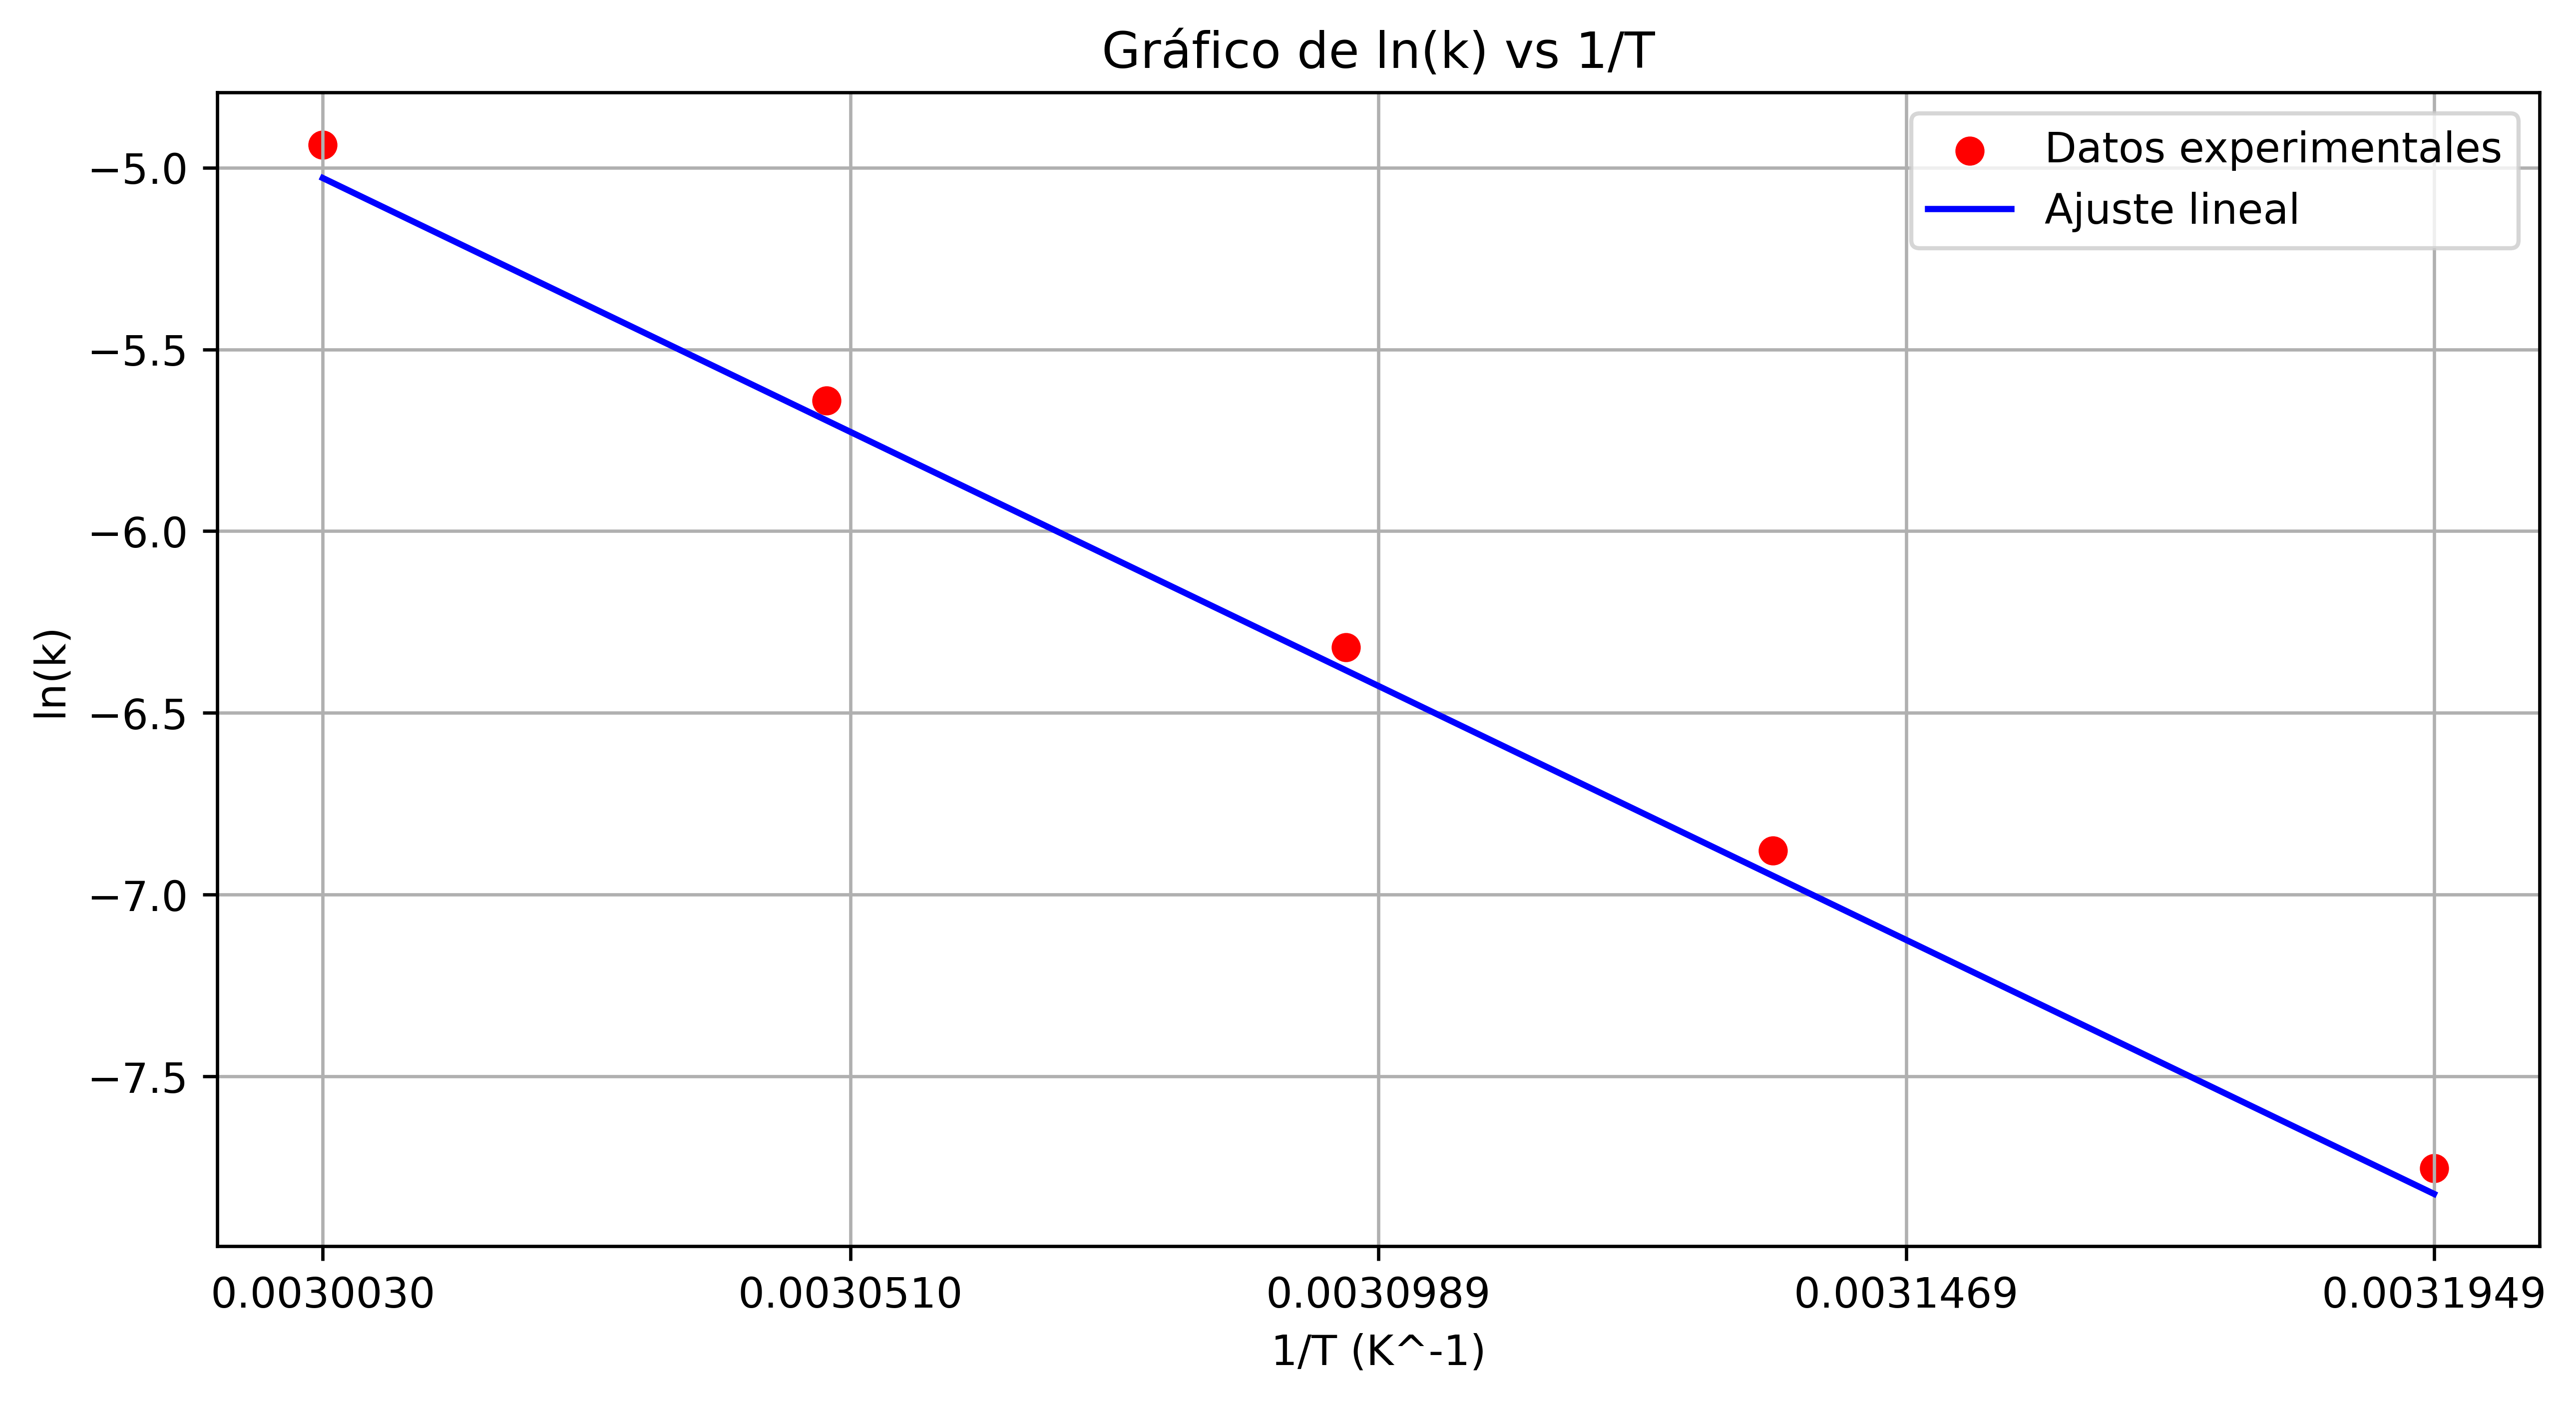

In [ ]:
# P3

# datos de temperatura y constantes de velocidad
T = np.array([313.0, 319.0, 323.0, 328.0, 333.0])  # K
k = np.array([0.00043, 0.00103, 0.00180, 0.00355, 0.00717])  # s^-1
# calcular ln(k) y 1/T
ln_k = np.log(k)
inv_T = 1 / T
# constantes de ajuste lineal (ln(k) = m * (1/T) + b) encontrados A MANO
m = -14561.667
b = 38.7
# datos de 1/T para graficar la línea de ajuste
muchos_inv_T = np.linspace(1 / 333, 1 / 313, 100)
# datos de ln(k) usando la forma lineal
muchos_ln_k = m * muchos_inv_T + b  
# Graficar
fig = plt.figure(figsize=(10, 5), dpi = 600)
plt.scatter(inv_T, ln_k, color='red', label='Datos experimentales')
plt.plot(muchos_inv_T, muchos_ln_k, color='blue', label='Ajuste lineal')
plt.xlabel('1/T (K^-1)')
plt.xticks(np.linspace(1/333, 1/313, 5))
plt.ylabel('ln(k)')
plt.title('Gráfico de ln(k) vs 1/T')
plt.legend()
plt.grid()
plt.show()

# P-N1

In [20]:
def func(x, a,b,c, d, e, f):    
    '''
    Función polinomial de grado 5 para ajuste de datos.
    Notemos que primero siempre va la variable independiente (x) 
    y luego los parámetros a ajustar (a,b,c,d,e,f).
    '''
    return a + b * x + c * x**2 + d * x**3 + e * x**4 + f * x**5
# datos desde el enunciado
X = [-1.0, -0.8947368421052632, -0.7894736842105263, -0.6842105263157895,
-0.5789473684210527, -0.4736842105263158, -0.368421052631579,
 -0.26315789473684215, -0.1578947368421053, -0.052631578947368474,
 0.05263157894736836, 0.1578947368421053, 0.26315789473684204,
 0.36842105263157876, 0.4736842105263157, 0.5789473684210527,
 0.6842105263157894, 0.7894736842105261, 0.894736842105263, 1.0]
y = [0.7600353290283648, 1.1976427418061653, 1.3900615328230448,
     1.4148503938574986, 1.3306802987407504, 1.180260353046269,
 0.9932636437792854, 0.7892530890663076, 0.5806072878446376,
 0.3754463695518873, 0.1805578438154953, 0.004322450142242141,
 -0.1403599923922323, -0.23314473545391423, -0.24331625176089844,
 -0.1268623853938718, 0.1764514978934008, 0.7460083603635945,
 1.6832653419853436, 3.1146796101227507]
# realizar el ajuste de la función a los datos
popt, pcov = sp.optimize.curve_fit(func, X, y) # curve_fit devuelve los parámetros óptimos (popt) y la covarianza de los parámetros (pcov)
print("Parámetros ajustados:", 
      f" a={popt[0]:.4f}, b={popt[1]:.4f}, c={popt[2]:.4f}, d={popt[3]:.4f}, e={popt[4]:.4f}, f={popt[5]:.4f}")

Parámetros ajustados:  a=0.2763, b=-1.8546, c=0.6239, d=1.1453, e=1.0372, f=1.8866


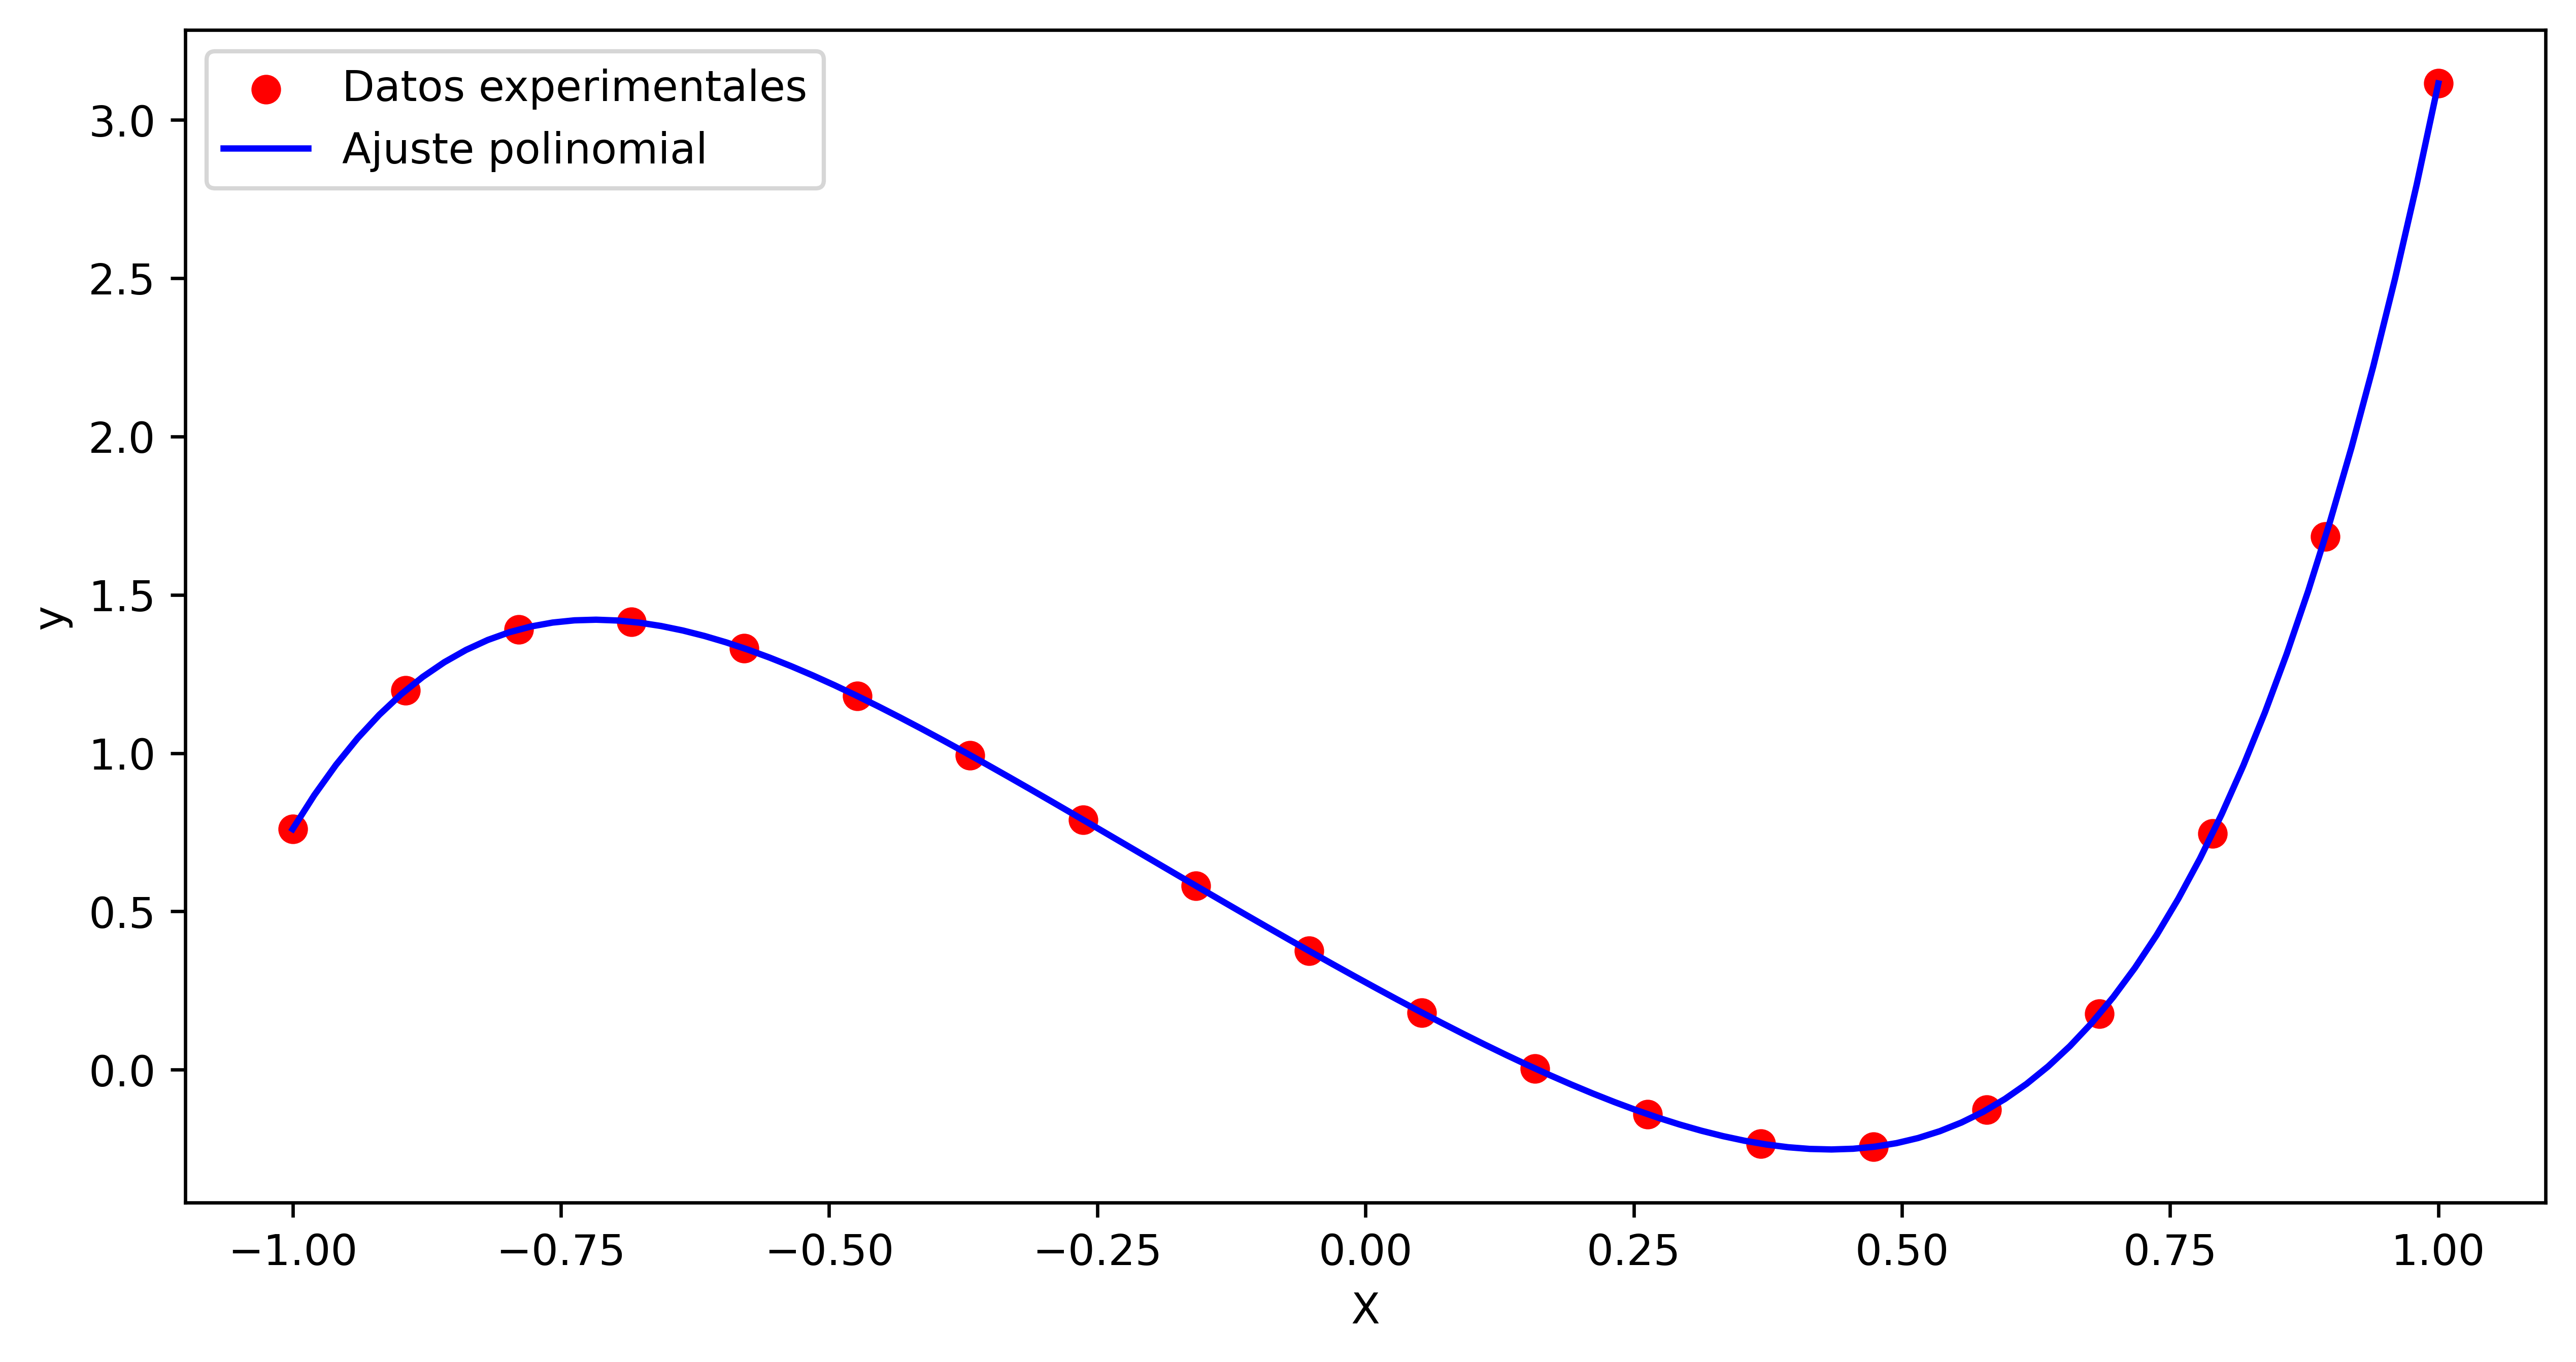

In [23]:
datos_con = np.linspace(min(X), max(X), 100) # datos para evaluar la función ajustada

#### COMENTARIO
# si a la funcion le pasamos un np.array funciona sino tira error 
ajuste = func(datos_con, popt[0], popt[1], popt[2], popt[3], popt[4], popt[5]) # evaluar la función ajustada en los datos_con
fig = plt.figure(figsize=(10, 5), dpi=600)
plt.scatter(X, y, color='red', label='Datos experimentales')
plt.plot(datos_con, ajuste, color='blue', label='Ajuste polinomial')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()


In [ ]:
y_estimado = func(np.array(X), # como la función espera un np.array (asi lo hace todo de una :D), convertimos X a np.array
                  popt[0], popt[1], popt[2], popt[3], popt[4], popt[5])
error_cuadratico_medio = np.sqrt(np.mean((y - y_estimado) ** 2))
print(f"Error cuadrático medio: {error_cuadratico_medio:.4f}")

Error cuadrático medio: 0.0000
